Dataset Shape: (4248, 20)


,Area Code,Date,Market,Market Size,Product,Product Line,Product Type,State,Type,Budget COGS,Budget Margin,Budget Profit,Budget Sales,COGS,Inventory,Margin,Marketing,Profit,Sales,Total Expenses
0,719,40909,Central,Major Market,Amaretto,Beans,Coffee,Colorado,Regular,90,130,100,220,89,777,130,24,94,219,36
1,970,40909,Central,Major Market,Colombian,Beans,Coffee,Colorado,Regular,80,110,80,190,83,623,107,27,68,190,39
2,970,40909,Central,Major Market,Decaf Irish Cream,Beans,Coffee,Colorado,Decaf,100,140,110,240,95,821,139,26,101,234,38
3,303,40909,Central,Major Market,Green Tea,Leaves,Tea,Colorado,Regular,30,50,30,80,44,623,56,14,30,100,26
4,303,40909,Central,Major Market,Caffe Mocha,Beans,Espresso,Colorado,Regular,60,90,70,150,54,456,80,15,54,134,26


Index(['Area Code', 'Date', 'Market', 'Market Size', 'Product', 'Product Line',
       'Product Type', 'State', 'Type', 'Budget COGS', 'Budget Margin',
       'Budget Profit', 'Budget Sales', 'COGS', 'Inventory', 'Margin',
       'Marketing', 'Profit', 'Sales', 'Total Expenses'],
      dtype='str')
Using text column: Market
TF-IDF Shape: (4248, 4)


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_6459/2450164050.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number o

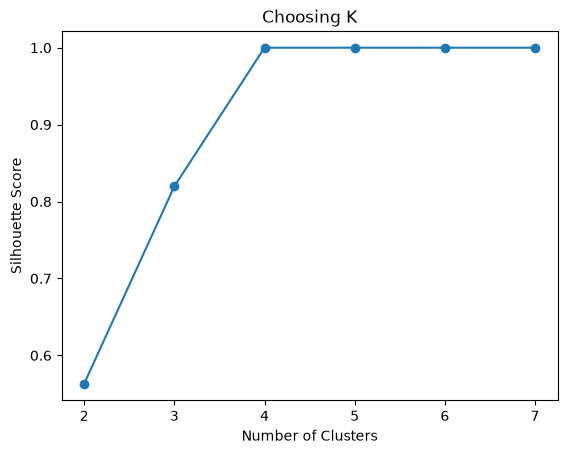


Cluster Counts:
Cluster
0    1560
1    1344
2    1344
Name: count, dtype: int64

Cluster 0:
east, south, west, central

Cluster 1:
central, west, south, east

Cluster 2:
west, south, east, central


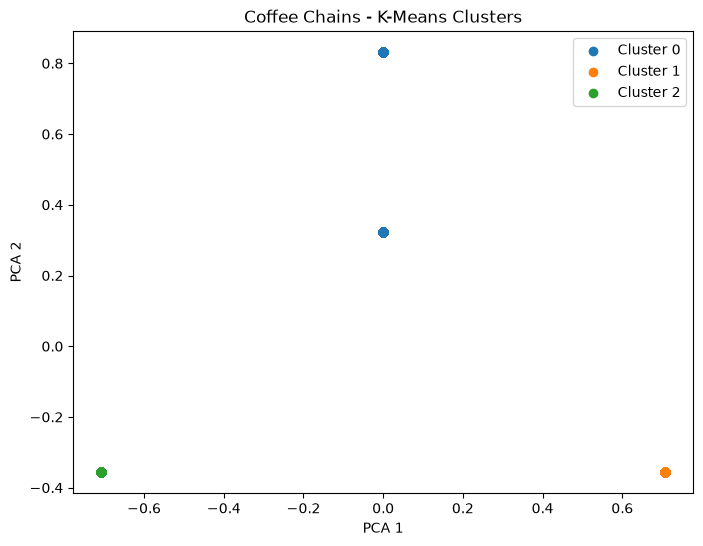

,Market,Cluster
0,Central,1
1,Central,1
2,Central,1
3,Central,1
4,Central,1
5,Central,1
6,Central,1
7,Central,1
8,Central,1
9,Central,1



Done!
Saved: coffee_chains_clustered.csv


In [1]:
# ============================================
# COFFEE CHAINS - NLP + K-MEANS
# ============================================

# 1. IMPORT LIBRARIES
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# 2. LOAD DATASET
df = pd.read_csv("coffee_chains.csv")

print("Dataset Shape:", df.shape)
display(df.head())
print(df.columns)


# 3. SELECT TEXT COLUMN
# Change this to your actual text column if needed
text_col = df.select_dtypes(include="object").columns[0]

print("Using text column:", text_col)


# 4. CLEAN TEXT
df[text_col] = df[text_col].fillna("").astype(str)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df[text_col].apply(clean_text)


# 5. NLP - TF-IDF
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(df["clean_text"])

print("TF-IDF Shape:", X.shape)


# 6. FIND BEST K USING SILHOUETTE SCORE
scores = []

for k in range(2, 8):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.plot(range(2, 8), scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Choosing K")
plt.show()


# 7. K-MEANS
# Change K after looking at the graph
K = 3

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)


# 8. CLUSTER COUNTS
print("\nCluster Counts:")
print(df["Cluster"].value_counts().sort_index())


# 9. TOP WORDS IN EACH CLUSTER
terms = vectorizer.get_feature_names_out()

for i in range(K):
    center = kmeans.cluster_centers_[i]
    top_words = center.argsort()[-10:][::-1]
    
    print(f"\nCluster {i}:")
    print(", ".join(terms[top_words]))


# 10. PCA FOR VISUALISATION
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))

for i in range(K):
    points = X_pca[df["Cluster"] == i]
    
    plt.scatter(
        points[:, 0],
        points[:, 1],
        label=f"Cluster {i}"
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Coffee Chains - K-Means Clusters")
plt.legend()
plt.show()


# 11. SHOW CLUSTERED DATA
display(df[[text_col, "Cluster"]].head(20))


# 12. SAVE RESULTS
df.to_csv("coffee_chains_clustered.csv", index=False)

print("\nDone!")
print("Saved: coffee_chains_clustered.csv")